In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

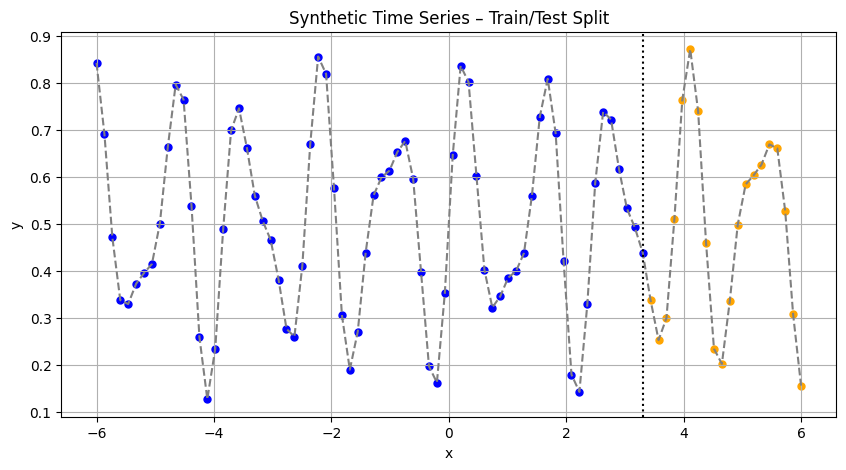

In [2]:
# ==== 1. Dane ====
x_all = np.linspace(-6, 6, 90)
y_all = (np.sin(5.0 * x_all) + 0.5 * np.sin(8.0 * x_all)) / 4 + 0.5

# ==== 2. Podział ====
x_train = x_all[:70]
y_train = y_all[:70]

x_test = x_all[70:]
y_test = y_all[70:]

# ==== 3. Wykres ====
plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, label="Target function", color="gray", linestyle="--")
plt.scatter(x_train, y_train, label="Train", color="blue", s=25)
plt.scatter(x_test, y_test, label="Test", color="orange", s=25)

# Linia podziału
plt.axvline(x=x_train[-1], color="black", linestyle=":", label="Train/Test split")

#plt.legend()
plt.title("Synthetic Time Series – Train/Test Split")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [3]:
# Parametry systemu
n_qubits = 3
n_ansatz_layers = 1
m_ansatz_layers = 2

def S(x):
    # RX(x) na wszystkich qubitach
    for i in range(n_qubits):
        qml.RX(x, wires=i)

def U_ent(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

def U_q(weights):
    for idx, w in enumerate(weights):
        qml.Rot(w[0], w[1], w[2], wires=idx)

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(device=dev)
def parralel_quantum_model(weights, x, n_ansatz_layers, m_ansatz_layers):
    
    U_ent(weights[:n_ansatz_layers])

    qml.Barrier()
    
    U_q(weights[n_ansatz_layers+1])
    
    qml.Barrier()
    
    S(x)
    
    qml.Barrier()

    U_ent(weights[n_ansatz_layers+1:-1])

    qml.Barrier()
    
    U_q(weights[-1])
    from functools import reduce
    import operator

    obs = reduce(operator.matmul, [qml.PauliZ(i) for i in range(n_qubits)])
    return qml.expval(obs)
    #return qml.expval( [qml.PauliZ(i) for i in range(n_qubits)] )
    #return qml.math.stack([qml.expval(qml.PauliZ(i)) for i in range(n_qubits)])

In [ ]:
weights = (np.random.random(size=(n_ansatz_layers+1+m_ansatz_layers+1, n_qubits, 3), requires_grad=True))

In [ ]:
print(qml.draw_mpl(parralel_quantum_model, level="device", decimals=2)(weights, np.pi, n_ansatz_layers, m_ansatz_layers))

In [ ]:
# # Koszt: MSE

def cost(weights, x_data, y_data):
    preds = []
    for x in x_data:
        out = parralel_quantum_model(weights, x, n_ansatz_layers, m_ansatz_layers)  # np. shape (3, 70)
        out_mean = qml.math.mean(out, axis=0)  # użyj qml.math, nie np.mean
        preds.append(out_mean)

    preds = qml.math.stack(preds)  # zlep w tablicę zgodną z autograd
    return qml.math.mean((preds - y_data) ** 2)  # scalar, działa z ArrayBox

# Optymalizacja
opt = qml.AdamOptimizer(stepsize=0.01)
epochs = 100

for epoch in range(epochs):
    weights = opt.step(
        lambda w: cost(w, x_train, y_train),
        weights
    )
    if epoch % 10 == 0:
        loss = cost(weights, x_train, y_train)
        print(f"Epoch {epoch}: loss = {loss:.6f}")


In [ ]:
y_pred_train.shape , x_train.shape

In [ ]:
# Predykcje
y_pred_train_out = np.array([parralel_quantum_model(weights, x, n_ansatz_layers, m_ansatz_layers) for x in x_train])
y_pred_test_out = np.array([parralel_quantum_model(weights, x, n_ansatz_layers, m_ansatz_layers) for x in x_test])

y_pred_train = qml.math.mean(y_pred_train_out, axis=1)
y_pred_test = qml.math.mean(y_pred_test_out, axis=1)

# Wykres
plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, label="Ground Truth", color="black", linewidth=1)
plt.scatter(x_train, y_pred_train, color="blue", label="Train prediction", s=12)
plt.scatter(x_test, y_pred_test, color="red", label="Test prediction", s=12)
plt.axvline(x=x_train[-1], color="gray", linestyle="--", label="Train/Test split")
plt.title("Serial Model")
plt.grid(True)
plt.legend()
plt.show()